In [35]:
# @title 1. Setup & Imports 🛠️
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from google.colab import drive
from IPython.display import display, Markdown

# Mount Google Drive
drive.mount('/content/drive')

# Configuration
ROOT_DIR = Path("/content/drive/MyDrive/an2dl-c2")
TRAIN_IMG_DIR = ROOT_DIR / "train_data"
TEST_IMG_DIR  = ROOT_DIR / "test_data"
TRAIN_LABELS_CSV = ROOT_DIR / "train_labels.csv"

# Plotting Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Setup Complete. Libraries loaded and Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup Complete. Libraries loaded and Drive mounted.


In [36]:
# @title 2. Define Analysis Functions 🧠
def get_image_stats(image_dir, label_df=None):
    """
    Scans a directory of images and returns a DataFrame with:
    - Dimensions (Height, Width)
    - Mean Color Channels (R, G, B)
    - Texture/color ratios
    """
    stats = []
    # Search for all pngs recursively
    all_files = list(image_dir.rglob("*.png"))

    print(f"📂 Scanning {len(all_files)} images in {image_dir.name}...")

    for filepath in tqdm(all_files):
        try:
            # Read image
            img = cv2.imread(str(filepath))
            if img is None: continue

            h, w, c = img.shape
            # Calculate means (BGR -> RGB)
            mean_b = np.mean(img[:, :, 0])
            mean_g = np.mean(img[:, :, 1])
            mean_r = np.mean(img[:, :, 2])

            # Match with label if available
            filename = filepath.name
            label = "Test (Unlabeled)"
            if label_df is not None:
                match = label_df[label_df['sample_index'] == filename]
                if not match.empty:
                    label = match['label'].values[0]

            stats.append({
                'filename': filename,
                'path': str(filepath),
                'dataset': 'Train' if label_df is not None else 'Test',
                'label': label,
                'height': h,
                'width': w,
                'mean_r': mean_r,
                'mean_g': mean_g,
                'mean_b': mean_b,
                # Simple heuristic: Tissue is Pink/Purple (High R, High B). Green is usually background/noise.
                'green_ratio': mean_g / (mean_r + 1e-5)
            })

        except Exception as e:
            print(f"❌ Error on {filepath.name}: {e}")

    return pd.DataFrame(stats)

def plot_image_tiles(df, title="Image Gallery", n=10, sort_by=None, ascending=False):
    """
    Displays a grid (tiles) of images. Useful for visual inspection.
    """
    if sort_by:
        subset = df.sort_values(by=sort_by, ascending=ascending).head(n)
    else:
        subset = df.sample(n=min(n, len(df)))

    plt.figure(figsize=(20, 4))
    plt.suptitle(title, fontsize=16, y=1.05)

    for i, (_, row) in enumerate(subset.iterrows()):
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{row['label']}\nR:{row['mean_r']:.0f} G:{row['mean_g']:.0f}\n{row['filename']}", fontsize=9)
        plt.axis('off')
    plt.show()

print("✅ Helper functions defined.")

✅ Helper functions defined.


In [37]:
# @title 3. Load Data & Calculate Statistics 📊

# 1. Load Labels
if TRAIN_LABELS_CSV.exists():
    df_labels = pd.read_csv(TRAIN_LABELS_CSV)
    print(f"📜 Loaded {len(df_labels)} labels.")
else:
    print("⚠️ Labels file not found! Check path.")

# 2. Process Images
df_train = get_image_stats(TRAIN_IMG_DIR, df_labels)
df_test = get_image_stats(TEST_IMG_DIR, None)

# 3. Combine
df_all = pd.concat([df_train, df_test], ignore_index=True)

display(Markdown(f"### ✅ Summary"))
print(f"Total Images Analyzed: {len(df_all)}")
print(f"Training Samples: {len(df_train)}")
print(f"Test Samples: {len(df_test)}")

📜 Loaded 1412 labels.
📂 Scanning 2824 images in train_data...


  0%|          | 0/2824 [00:00<?, ?it/s]

📂 Scanning 1908 images in test_data...


  0%|          | 0/1908 [00:00<?, ?it/s]

### ✅ Summary

Total Images Analyzed: 4732
Training Samples: 2824
Test Samples: 1908


/tmp/ipython-input-861514468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='label',


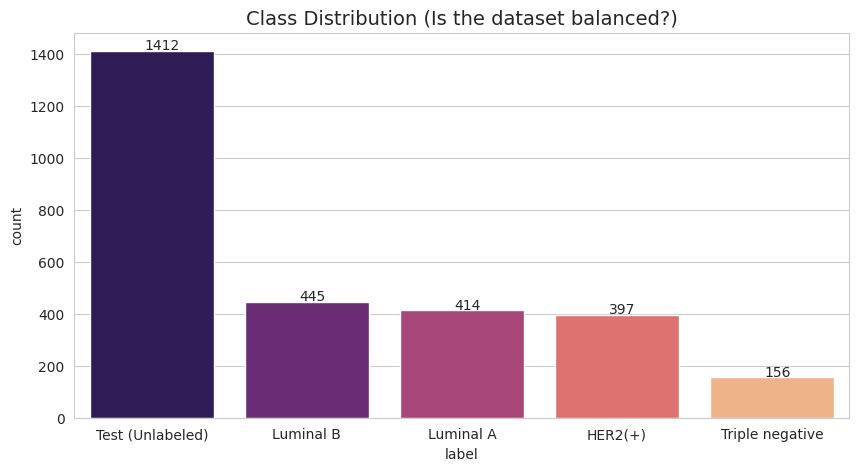

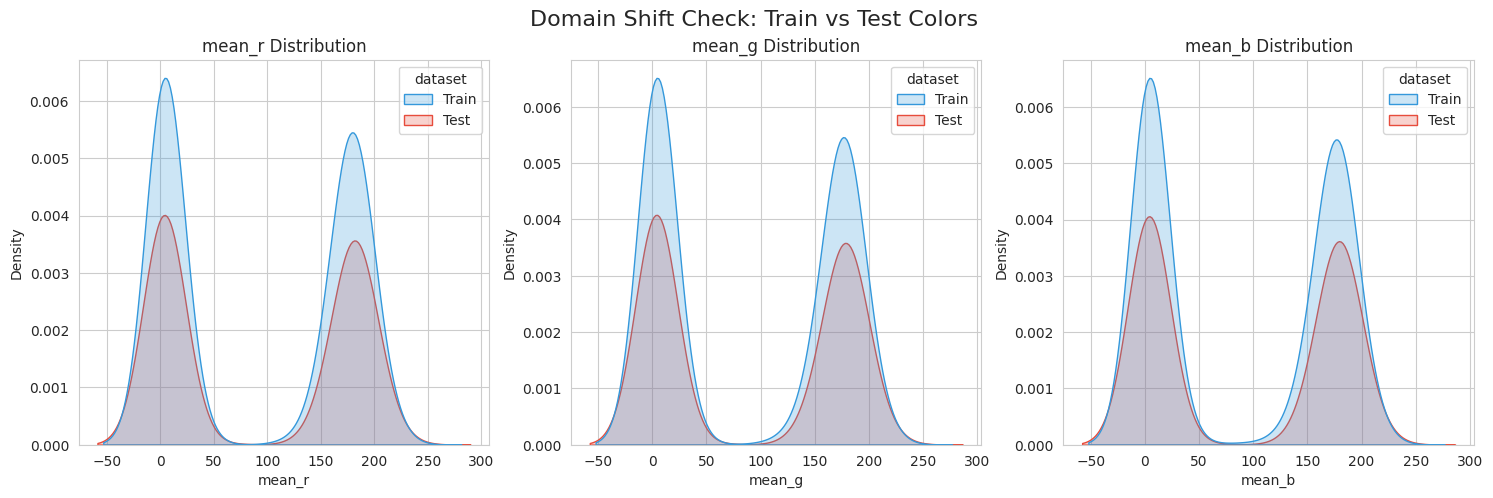

In [29]:
# @title 4. Distribution Analysis 📈

# A. Class Imbalance
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_train, x='label',
                   order=df_train['label'].value_counts().index,
                   palette='magma')
plt.title("Class Distribution (Is the dataset balanced?)", fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.35, p.get_height()+5))
plt.show()

# B. Train vs Test Shift (Color Distribution)
# If these curves don't overlap, your model might fail on the leaderboard.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, color) in enumerate(zip(['mean_r', 'mean_g', 'mean_b'], ['red', 'green', 'blue'])):
    sns.kdeplot(data=df_all, x=col, hue='dataset', fill=True, ax=axes[i],
                palette={'Train': '#3498db', 'Test': '#e74c3c'})
    axes[i].set_title(f'{col} Distribution')
plt.suptitle("Domain Shift Check: Train vs Test Colors", fontsize=16)
plt.show()

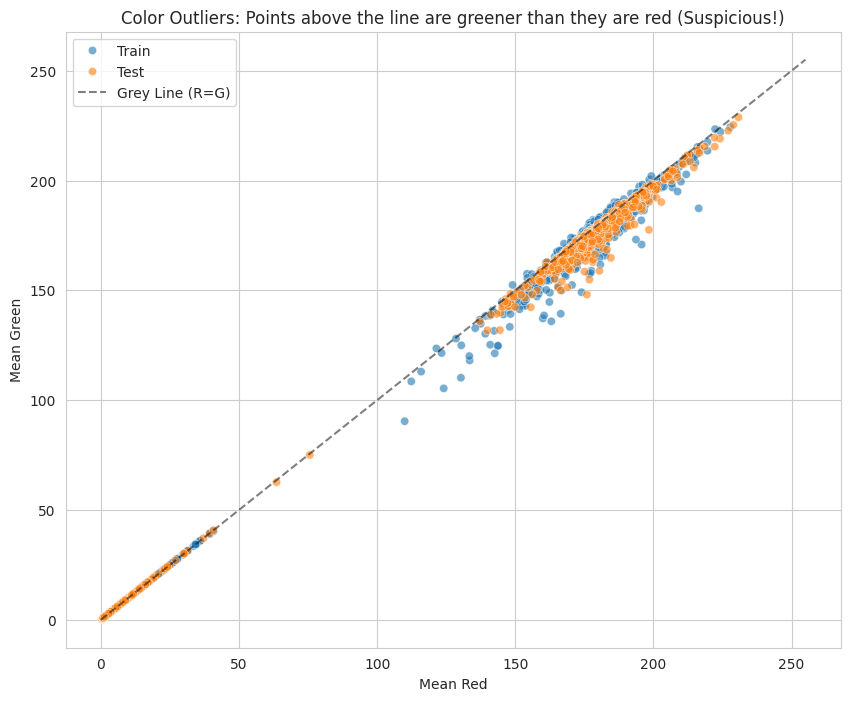

### 🖼️ Visualizing Potential Anomalies

Top 5 Images with highest Green/Red ratio:


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 129314 (\N{NAUSEATED FACE}) missing from font(s) DejaVu Sans.



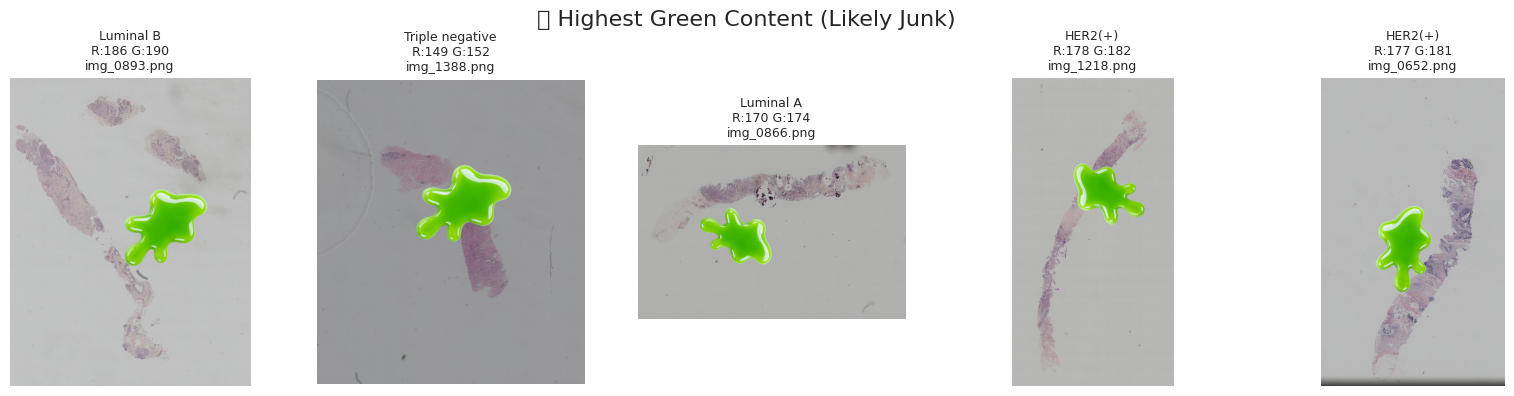

Top 5 Darkest Images:


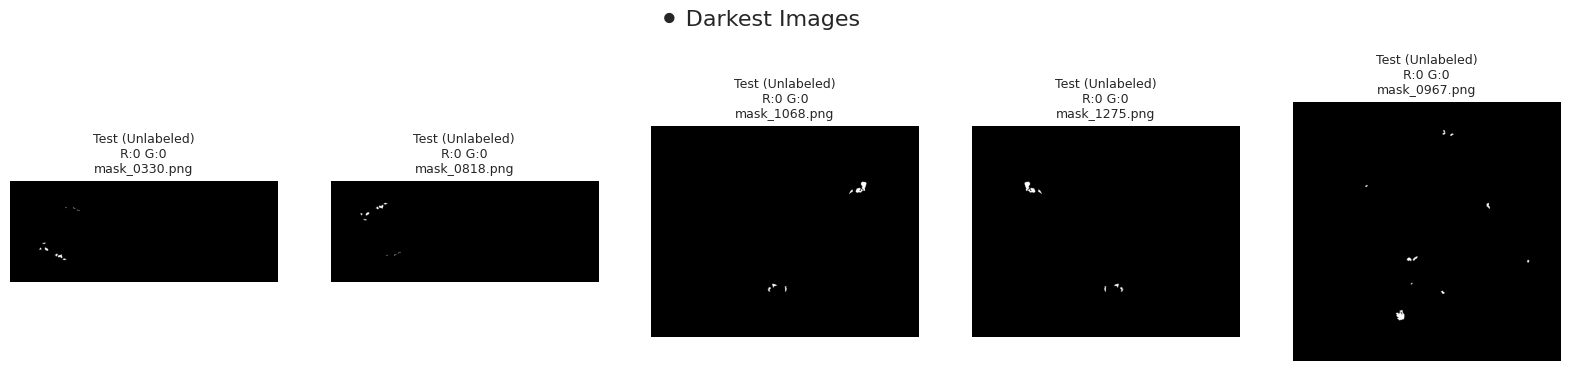

Top 5 Weirdest Shapes:


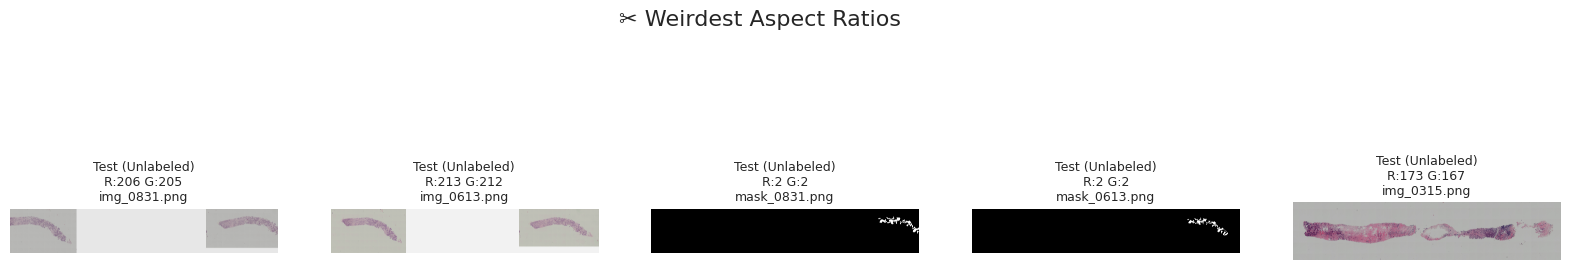

In [38]:
# @title 5. Anomaly Detection & Quality Control 🕵️‍♂️

# 1. Color Outliers (The "Shrek" Plot)
# Tissue = High Red/Blue. Noise = High Green or Black.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_all, x='mean_r', y='mean_g', hue='dataset', alpha=0.6)
plt.plot([0, 255], [0, 255], 'k--', alpha=0.5, label='Grey Line (R=G)')
plt.title("Color Outliers: Points above the line are greener than they are red (Suspicious!)")
plt.xlabel("Mean Red")
plt.ylabel("Mean Green")
plt.legend()
plt.show()

# 2. Visualize the weirdest images
display(Markdown("### 🖼️ Visualizing Potential Anomalies"))

# Top Greenest Images (Likely marker pens, artifacts, or 'Shrek')
print("Top 5 Images with highest Green/Red ratio:")
plot_image_tiles(df_all, title="🤢 Highest Green Content (Likely Junk)", n=5, sort_by='green_ratio', ascending=False)

# Top Darkest Images (Likely empty slides or artifacts)
df_all['brightness'] = (df_all['mean_r'] + df_all['mean_g'] + df_all['mean_b']) / 3
print("Top 5 Darkest Images:")
plot_image_tiles(df_all, title="⚫ Darkest Images", n=5, sort_by='brightness', ascending=True)

# Weird Aspect Ratios (Cut images)
df_all['ar_dev'] = np.abs(df_all['width'] / df_all['height'] - 1.0) # Deviation from square
print("Top 5 Weirdest Shapes:")
plot_image_tiles(df_all, title="✂️ Weirdest Aspect Ratios", n=5, sort_by='ar_dev', ascending=False)

In [41]:
# @title 6. Data Leakage & Duplicate Detection (With Lists) 📝
import hashlib

def get_file_hash(filepath):
    """Calculates MD5 hash of file content to find exact duplicates"""
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

print("🔍 Hunting for duplicates... this detects EXACT file copies.")

# 1. Calculate Hashes
# We use a progress bar because this reads every file
df_all['file_hash'] = [get_file_hash(row['path']) for _, row in tqdm(df_all.iterrows(), total=len(df_all))]

# 2. Find Duplicates
# Group by hash and filter for groups larger than 1
duplicates = df_all.groupby('file_hash').filter(lambda x: len(x) > 1)

if not duplicates.empty:
    # A. Check for Train-Test Leakage (CRITICAL)
    # Leakage happens if a hash group contains both 'Train' and 'Test' labels
    leakage_groups = duplicates.groupby('file_hash')['dataset'].nunique()
    leakage_hashes = leakage_groups[leakage_groups > 1].index

    if len(leakage_hashes) > 0:
        print(f"\n🚨 CRITICAL ALERT: Found {len(leakage_hashes)} pairs of Train-Test Leakage!")
        print("These Test images are exact copies of Training images.")
        print("-" * 60)
        for h in leakage_hashes:
            group = duplicates[duplicates['file_hash'] == h]
            print(f"Hash {h[:8]}... maps to:")
            for _, row in group.iterrows():
                print(f"  - [{row['dataset']}] {row['filename']} (Label: {row['label']})")
    else:
        print("\n✅ Good news: No exact Train-Test leakage found.")

    # B. Check for Internal Duplicates (Train-Train or Test-Test)
    # This is less critical but good to clean up
    internal_dupes = duplicates[~duplicates['file_hash'].isin(leakage_hashes)]

    if not internal_dupes.empty:
        print(f"\n⚠️ Found {len(internal_dupes['file_hash'].unique())} groups of internal duplicates.")
        print("You should remove the copies to prevent bias.")
        print("-" * 60)
        # List first 10 groups to avoid spamming output
        for h in internal_dupes['file_hash'].unique()[:10]:
            group = internal_dupes[internal_dupes['file_hash'] == h]
            print(f"Hash {h[:8]}... contains:")
            for _, row in group.iterrows():
                print(f"  - {row['filename']}")
        if len(internal_dupes['file_hash'].unique()) > 10:
            print("... and more.")

else:
    print("\n✅ Clean dataset! No duplicates found anywhere.")

🔍 Hunting for duplicates... this detects EXACT file copies.


  0%|          | 0/4732 [00:00<?, ?it/s]


✅ Good news: No exact Train-Test leakage found.

⚠️ Found 169 groups of internal duplicates.
You should remove the copies to prevent bias.
------------------------------------------------------------
Hash c4bf1e69... contains:
  - mask_0772.png
  - mask_0582.png
Hash 870b2801... contains:
  - mask_1336.png
  - mask_0529.png
Hash 50fcbaf8... contains:
  - mask_0438.png
  - mask_0810.png
Hash a795d093... contains:
  - mask_0564.png
  - mask_0147.png
Hash 1a18a6bf... contains:
  - mask_0771.png
  - mask_1194.png
Hash 0cc79019... contains:
  - mask_0413.png
  - mask_0275.png
Hash 1533e7ae... contains:
  - mask_1335.png
  - mask_0851.png
Hash 12eaed44... contains:
  - mask_0981.png
  - mask_0703.png
Hash 67a0ac0a... contains:
  - mask_0997.png
  - mask_0631.png
Hash bc64fb28... contains:
  - mask_0773.png
  - mask_0454.png
... and more.


In [42]:
# @title 7. Interactive Outlier Explorer 🖱️
import plotly.express as px

# Create an interactive scatter plot
fig = px.scatter(
    df_all,
    x='mean_r',
    y='mean_g',
    color='dataset',
    hover_data=['filename', 'label', 'width', 'height'],
    title='Interactive Color Analysis (Hover to see Filenames!)',
    opacity=0.6,
    color_discrete_map={'Train': 'blue', 'Test': 'orange'}
)

# Add the "Grey Line" (R=G)
fig.add_shape(
    type="line", line=dict(dash='dash', color='gray'),
    x0=0, y0=0, x1=255, y1=255
)

fig.show()

print("💡 TIP: Hover over the points that are far above the diagonal line.")
print("Those are your 'Shrek' images or green marker artifacts.")
print("Note the filenames and remove them from training!")

💡 TIP: Hover over the points that are far above the diagonal line.
Those are your 'Shrek' images or green marker artifacts.
Note the filenames and remove them from training!
